# PEPS ML Decoder Threshold: Logical vs Physical Error Rate

Verify that the PEPS ML decoder suppresses the logical error rate below the physical error rate for small enough p.

## Full logical error rate

The PEPS decoder predicts all 4 cosets `(lx, lz)` simultaneously from both sX and sZ syndromes.
To measure the **full** logical error rate (both X and Z logical observables), we run two independent experiments:

- `memory_x` → Stim observable = Z-type logical flip → compare with coset index `lz`
- `memory_z` → Stim observable = X-type logical flip → compare with coset index `lx`

Under code-capacity depolarizing noise, X and Z error channels are independent:
$$p_L^\text{full} = 1 - (1 - p_L^X)(1 - p_L^Z)$$

## Runtime note

PEPS decoding is shot-by-shot. Each contraction takes O(1) seconds depending on `Nkeep`.
Reduce `shots` or `Nkeep` if runtime is too long.
Typical setting: `shots=200`, `Nkeep=32` → a few minutes per `(d, p)` point.

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
from src.stim_PEPS_wrapper import run_surface_code_peps_full_logical

In [4]:
# ── Sweep parameters ──────────────────────────────────────────────────────────
distances = [3, 5]                         # surface code distances (7 is slow)
p_values  = np.geomspace(0.01, 0.20, 10)  # physical error rates
shots     = 100                            # samples per (distance, p, basis)
Nkeep     = 32                             # PEPS bond dimension (accuracy vs speed)
Nsweep    = 1

print(f'Total PEPS contractions: {len(distances) * len(p_values) * shots * 2}')
print(f'  distances={distances}, p_values={len(p_values)}, shots={shots}, bases=2')

Total PEPS contractions: 4000
  distances=[3, 5], p_values=10, shots=100, bases=2


In [5]:
# ── Run sweep ─────────────────────────────────────────────────────────────────
# results[d] = {'p_L_X': [...], 'p_L_Z': [...], 'p_L_full': [...]}
results = {}

for d in distances:
    print(f'\ndistance = {d}')
    p_L_X, p_L_Z, p_L_full = [], [], []
    for p in p_values:
        print(f'  p = {p:.4f}')
        res = run_surface_code_peps_full_logical(
            distance=d,
            p=float(p),
            shots=shots,
            Nkeep=Nkeep,
            Nsweep=Nsweep,
            verbose=True,
        )
        p_L_X.append(res.p_L_X)
        p_L_Z.append(res.p_L_Z)
        p_L_full.append(res.logical_error_rate)
        print(f'    → p_L_X={res.p_L_X:.4f}  p_L_Z={res.p_L_Z:.4f}  p_L_full={res.logical_error_rate:.4f}')
    results[d] = {
        'p_L_X':    np.array(p_L_X),
        'p_L_Z':    np.array(p_L_Z),
        'p_L_full': np.array(p_L_full),
    }

print('\nDone.')


distance = 3
  p = 0.0100
  memory_x (lz):
    shot 0/100
    shot 10/100
    shot 20/100
    shot 30/100
    shot 40/100
    shot 50/100
    shot 60/100
    shot 70/100
    shot 80/100
    shot 90/100
  memory_z (lx):
    shot 0/100
    shot 10/100
    shot 20/100
    shot 30/100
    shot 40/100
    shot 50/100
    shot 60/100
    shot 70/100
    shot 80/100
    shot 90/100
    → p_L_X=0.1000  p_L_Z=0.0500  p_L_full=0.1450
  p = 0.0139
  memory_x (lz):
    shot 0/100
    shot 10/100
    shot 20/100
    shot 30/100
    shot 40/100
    shot 50/100
    shot 60/100
    shot 70/100
    shot 80/100
    shot 90/100
  memory_z (lx):
    shot 0/100
    shot 10/100
    shot 20/100
    shot 30/100
    shot 40/100
    shot 50/100
    shot 60/100
    shot 70/100
    shot 80/100
    shot 90/100
    → p_L_X=0.0500  p_L_Z=0.1000  p_L_full=0.1450
  p = 0.0195
  memory_x (lz):
    shot 0/100
    shot 10/100
    shot 20/100
    shot 30/100
    shot 40/100
    shot 50/100
    shot 60/100
    shot 70/100

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

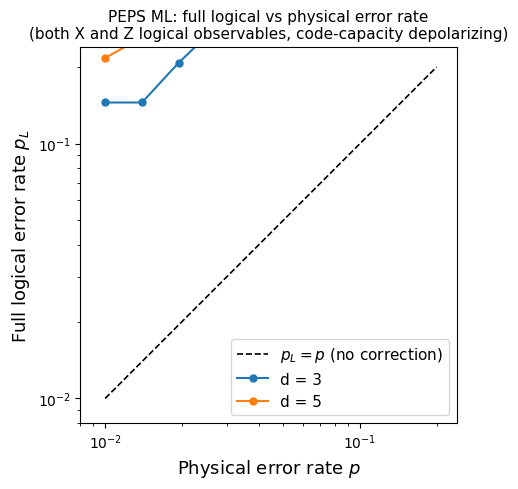

Saved peps_threshold.png


In [6]:
# ── Plot: full logical error rate ─────────────────────────────────────────────
colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(p_values, p_values, 'k--', linewidth=1.2, label='$p_L = p$ (no correction)')

for d, color in zip(distances, colors):
    ax.plot(p_values, results[d]['p_L_full'], 'o-',
            color=color, label=f'd = {d}', markersize=5)

ax.set_xlabel('Physical error rate $p$', fontsize=13)
ax.set_ylabel('Full logical error rate $p_L$', fontsize=13)
ax.set_title(
    'PEPS ML: full logical vs physical error rate\n'
    '(both X and Z logical observables, code-capacity depolarizing)',
    fontsize=11,
)
ax.legend(fontsize=11)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_aspect('equal')
ax.set_xlim(p_values[0] * 0.8, p_values[-1] * 1.2)
ax.set_ylim(p_values[0] * 0.8, p_values[-1] * 1.2)

plt.tight_layout()
plt.savefig('peps_threshold.png', dpi=150)
plt.show()
print('Saved peps_threshold.png')

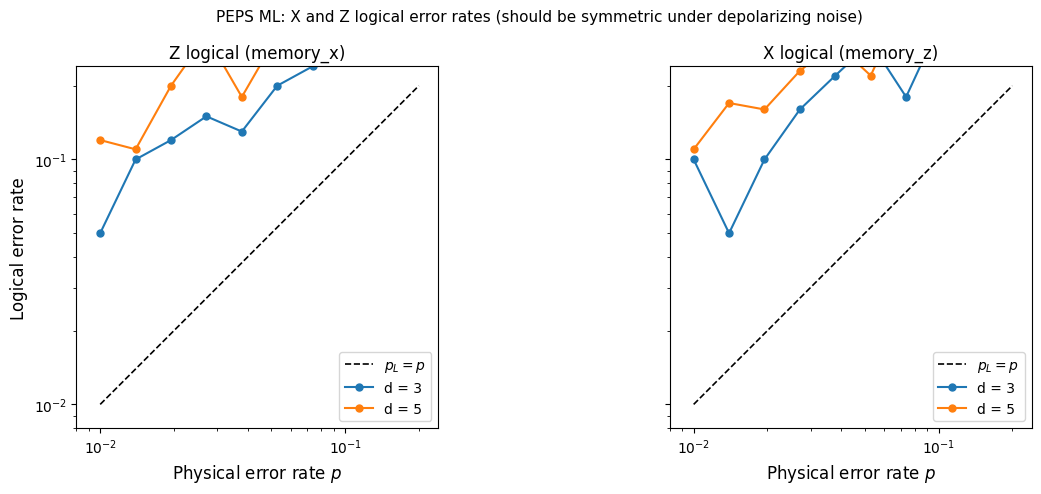

In [7]:
# ── Optional: X and Z rates separately (should be symmetric) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, key, label in zip(axes, ['p_L_Z', 'p_L_X'], ['Z logical (memory_x)', 'X logical (memory_z)']):
    ax.plot(p_values, p_values, 'k--', linewidth=1.2, label='$p_L = p$')
    for d, color in zip(distances, colors):
        ax.plot(p_values, results[d][key], 'o-', color=color, label=f'd = {d}', markersize=5)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Physical error rate $p$', fontsize=12)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_aspect('equal')
    ax.set_xlim(p_values[0] * 0.8, p_values[-1] * 1.2)
    ax.set_ylim(p_values[0] * 0.8, p_values[-1] * 1.2)
    ax.legend(fontsize=10)

axes[0].set_ylabel('Logical error rate', fontsize=12)
fig.suptitle('PEPS ML: X and Z logical error rates (should be symmetric under depolarizing noise)', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# ── Summary table ─────────────────────────────────────────────────────────────
col_w = 12
header = f"{'p':>8}" + "".join(
    f"{'d='+str(d)+' pLX':>{col_w}}{'d='+str(d)+' pLZ':>{col_w}}{'d='+str(d)+' full':>{col_w}}"
    for d in distances
)
print(header)
print('-' * len(header))
for i, p in enumerate(p_values):
    row = f"{p:8.4f}" + "".join(
        f"{results[d]['p_L_X'][i]:{col_w}.4f}"
        f"{results[d]['p_L_Z'][i]:{col_w}.4f}"
        f"{results[d]['p_L_full'][i]:{col_w}.4f}"
        for d in distances
    )
    print(row)